# Lesson 9: Choice + Reaction Time Models — DDM and Race-Diffusion

So far we have modelled **only the choice** that participants make on each trial.
But behaviour also has a *temporal* signature: how long the participant deliberated.
Reaction times (RT) carry information that choice-only models discard. Two trials
with the same choice can differ wildly in confidence, evidence quality, or
deliberation effort — and those differences shape RT.

This lesson introduces bauer's two **joint choice + RT** model families:

1. **Drift-Diffusion Model (DDM)** — a single accumulator integrates a *signed*
   evidence signal (option 2 minus option 1) until it hits one of two boundaries.
2. **Race-Diffusion Model (RDM)** — two parallel accumulators, one per option,
   each integrating its own evidence stream until one wins.

Both reuse the **same Bayesian-observer cognitive front-end** as the static
psychometric models from lessons 1–4 (priors, asymmetric encoding noise, the
shrinkage weights $\beta_k$). What changes is only the **decision rule**: instead
of a one-shot cumulative-normal comparison, we now have a stochastic accumulation
process whose first-passage time *is* the participant's RT.

## Why care about RT?

A choice-only model fits $P(\text{choose 2})$ and ignores the RT distribution.
That throws away three pieces of information:

1. **The size effect.** On magnitude tasks, RT systematically *decreases* with
   stimulus magnitude even at fixed difficulty (fixed $\log(n_2/n_1)$). Bigger
   numbers $\Rightarrow$ bigger drift rates $\Rightarrow$ faster races. Choice-only
   models are silent on this — they have no notion of how long a decision took.
2. **Identifiability.** Choice probabilities are invariant to many transformations
   of the underlying parameters (e.g. scaling all noise SDs by a constant
   leaves $P$ unchanged if the SNR is preserved). RT distributions break those
   degeneracies because the *absolute* speed of accumulation matters, not just
   the relative SNR.
3. **Falsification.** A model that fits choice probabilities but predicts the
   wrong RT distributions is wrong in a falsifiable way. Joint choice+RT models
   are simply a stricter test of the underlying cognitive theory.

In this lesson we use the Barreto-Garcia et al. (2022) magnitude task to fit
both DDM and RDM variants, compare their posteriors, and see how the
**race-model "advantage" decomposition** of drift is essential for capturing
choice — using the wrong decomposition produces a flat psychometric.

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

sns.set_theme(context='notebook', style='whitegrid', palette='deep')

from bauer.utils.data import load_garcia2022
from bauer.models import (
    MagnitudeComparisonModel,
    DDMMagnitudeComparisonModel,
    RaceDiffusionMagnitudeComparisonModel,
)

# Load the magnitude task and subset to 8 subjects to keep fits short.
df_full = load_garcia2022(task='magnitude')
subs = df_full.index.get_level_values('subject').unique()[:8]
df = df_full.loc[df_full.index.get_level_values('subject').isin(subs)].copy()

# ── Preprocess: drop physiologically implausible fast trials ──────────────
# Same RT filter as lesson 8 — see that lesson for the full pedagogical
# motivation. Without it, the per-subject _t0_cap (= 0.95 * min rt) sits
# below the t0 prior centre for most subjects, squeezing t0 against the cap
# and funneling t0_sd through the HalfCauchy heavy tail. Concretely, for
# this RDM fit, dropping it cuts divergences from ~80 to ~1.
RT_MIN = 0.20
n_before = len(df)
df = df[df['rt'] >= RT_MIN].copy()
n_subj = df.index.get_level_values('subject').nunique()
print(f"Subjects: {n_subj}")
print(f"Trials:   {len(df)}  (~{len(df) // n_subj} per subject)")
print(f"Columns:  {list(df.columns)}")
print(f"\nDropped {n_before - len(df)} / {n_before} trials with rt < {RT_MIN:.2f}s "
      f"({100*(n_before - len(df))/n_before:.1f}%); min rt now {df['rt'].min():.3f}s.")

# Cache directory for fitted idata, so re-running the notebook after a
# downstream cell change doesn't redo the (~5-15 min) fits. Set
# BAUER_TUTORIAL_REFIT=1 in the env to force a fresh fit. Cache key
# encodes the RT cutoff so a future change there gets a fresh cache.
CACHE_DIR = os.path.expanduser('~/.bauer_tutorial_cache')
os.makedirs(CACHE_DIR, exist_ok=True)
FORCE_REFIT = bool(os.environ.get('BAUER_TUTORIAL_REFIT', ''))
CACHE_TAG = f'garcia_n{n_subj}_rtmin{int(RT_MIN*1000)}'

def fit_or_load(model, name, draws=600, tune=600, chains=4, target_accept=0.95):
    path = os.path.join(CACHE_DIR, f'{CACHE_TAG}_{name}.nc')
    if os.path.exists(path) and not FORCE_REFIT:
        print(f"Loading cached {name} fit from {path}")
        return az.from_netcdf(path)
    model.build_estimation_model(data=df, hierarchical=True)
    idata = model.sample(draws=draws, tune=tune, chains=chains,
                          target_accept=target_accept)
    idata.to_netcdf(path)
    print(f"Saved {name} fit to {path}")
    return idata


def add_bins(d, n_stake_bins=4, n_diff_bins=3):
    """Annotate a paradigm DataFrame with stake / difficulty bins and the
    'correct' bool. Used by every size-effect plot below."""
    d = d.copy()
    d['stake'] = np.sqrt(d['n1'] * d['n2'])
    d['log_stake'] = np.log(d['stake'])
    d['log_ratio'] = np.log(d['n2'] / d['n1'])
    d['abs_log_ratio'] = d['log_ratio'].abs()
    d['stake_bin'] = pd.qcut(d['log_stake'], n_stake_bins, labels=False,
                              duplicates='drop')
    d['diff_bin'] = pd.qcut(d['abs_log_ratio'], n_diff_bins,
                             labels=['hard', 'medium', 'easy'][:n_diff_bins],
                             duplicates='drop')
    d['stake_mid'] = d.groupby('stake_bin', observed=True)['stake'] \
                      .transform('mean')
    if 'choice' in d.columns:
        d['correct'] = d['choice'].astype(bool) == (d['n2'] > d['n1'])
    return d

df.head()

Subjects: 8
Trials:   1568  (~196 per subject)
Columns:  ['n1', 'n2', 'choice', 'rt', 'accuracy', 'correct', 'isi']

Dropped 67 / 1635 trials with rt < 0.20s (4.1%); min rt now 0.202s.


n1  n2  choice     rt  accuracy  correct  \
subject format       run trial_nr                                             
1       non-symbolic 1   1          7  10    True  0.775         1       -1   
                         2          5  14   False  0.892         0       -1   
                         3          7  14    True  0.611         1       -1   
                         4          7  10    True  0.660         1       -1   
                         5          5  10    True  0.830         1       -1   

                                     isi  
subject format       run trial_nr         
1       non-symbolic 1   1         8.033  
                         2         8.532  
                         3         6.533  
                         4         7.033  
                         5         9.033

## The size effect in the data

Before fitting any model, let's look at the empirical RT distribution. The
**size effect** is one of the most robust phenomena in numerical cognition: at
fixed log-ratio difficulty, larger stimulus magnitudes are decided *faster*.
This emerges automatically from a Bayesian-observer + drift-diffusion theory
(larger posterior log-mean $\Rightarrow$ larger drift), but a choice-only
psychometric model can't say anything about it.

We bin trials by the geometric mean $\sqrt{n_1 n_2}$ ("stake size") and by
absolute log-ratio (difficulty), then average within each subject before
plotting — so the 95% CI reflects between-subject variability, not the much
larger trial-to-trial variability.

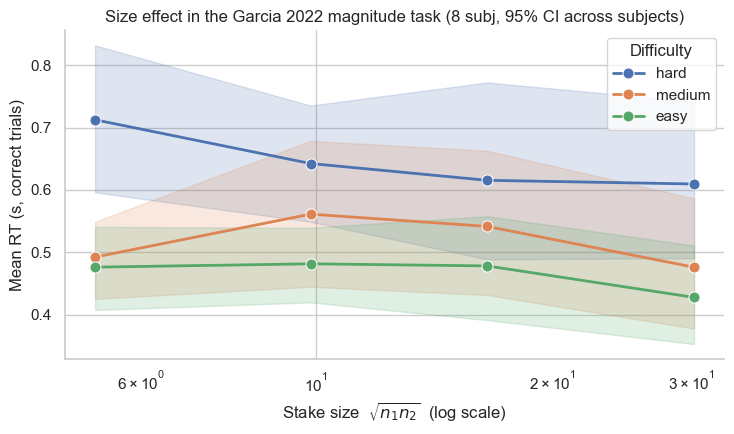

In [ ]:
db = add_bins(df)
db_corr = db[db['correct']]

# Per-subject mean RT in each (stake_bin, diff_bin) cell. Aggregating *within*
# subject first means the across-subject CI is a clean measure of the size
# effect's reliability across the population.
sub_agg = (db_corr.groupby(['subject', 'stake_bin', 'stake_mid', 'diff_bin'],
                            observed=True)['rt'].mean().reset_index())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.lineplot(data=sub_agg, x='stake_mid', y='rt', hue='diff_bin',
             hue_order=['hard', 'medium', 'easy'],
             errorbar=('ci', 95), marker='o', lw=2, ms=8,
             err_style='band', err_kws={'alpha': 0.18},
             ax=ax)
ax.set_xscale('log')
ax.set_xlabel(r'Stake size  $\sqrt{n_1 n_2}$  (log scale)')
ax.set_ylabel('Mean RT (s, correct trials)')
ax.set_title('Size effect in the Garcia 2022 magnitude task '
             '(8 subj, 95% CI across subjects)')
ax.legend(title='Difficulty', loc='upper right')
sns.despine()
plt.tight_layout()

Mean RT decreases with stake size at every difficulty level — a clean size
effect. **A choice-only model cannot reproduce this curve at all** because it
has no RT in its likelihood. To fit it, we need a process model with an
explicit time variable.

## The Drift-Diffusion Model

The DDM (Ratcliff 1978; Bogacz et al. 2006) treats the decision as the
integration of a single noisy evidence signal until one of two boundaries is
hit. For a 2AFC magnitude comparison, the evidence signal is the *signed*
posterior difference:

$$\mathrm{d}X(t) = v\, \mathrm{d}t + \sigma\, \mathrm{d}W(t),
\qquad v = \frac{\mu_{\text{post},2} - \mu_{\text{post},1}}{\sqrt{\nu_1^2 + \nu_2^2}}$$

Drift is the **subjective signal-to-noise ratio** of the perceived log-magnitude
difference. Diffusion noise $\sigma$ is fixed at 1 (HSSM convention; the
boundary absorbs the SNR scale). Three new parameters enter:

| symbol | meaning |
|---|---|
| $a$ | half boundary separation (full boundary = $2a$) |
| $z$ | normalized starting point in $[0, 1]$; bauer defaults to $z = 0.5$ (unbiased) |
| $t_0$ | non-decision time (motor + sensory delay), in seconds |

The first-passage-time density is the analytic Wiener WFPT (Navarro & Fuss
2009), provided by HSSM. Positive drift $\Rightarrow$ upper boundary hit first
$\Rightarrow$ `choice = True` (option 2 chosen).

### What does drift inherit from the cognitive front-end?

The Bayesian-observer mixing weights $\beta_k = \sigma_p^2 / (\sigma_p^2 + \nu_k^2)$
appear in the *numerator* of $v$ (through $\mu_{\text{post},k}$). The denominator
$\sqrt{\nu_1^2 + \nu_2^2}$ uses the raw encoding SDs. So:

- **Asymmetric noise** ($\nu_1 \neq \nu_2$): drift gets pulled toward the prior
  more for the noisier option, exactly as in the static psychometric.
- **Tight prior** ($\sigma_p \to 0$): both posterior means collapse to $\mu_p$,
  drift collapses to zero, and the DDM predicts no choice information and very
  long RTs — the agent is overruled by the prior.

These mechanisms come for free from the cognitive front-end. The DDM only adds
$a$, $t_0$ (and optionally $z$, $v_{\text{scale}}$) on top.

In [ ]:
# ── Fit the DDM on 8 subjects ──────────────────────────────────────────────
# This will take ~5–15 minutes on a laptop with the pymc backend.
# Sampler defaults: tune=1000, draws=1000, chains=4, target_accept=0.95;
# the tutorial uses tune/draws=600 to keep wall time manageable.

m_ddm = DDMMagnitudeComparisonModel(
    paradigm=df,
    fit_separate_evidence_sd=True,   # allow ν_1 ≠ ν_2 (sequential task)
    fit_prior=True,                  # estimate Bayesian-observer prior μ_p, σ_p
)
idata_ddm = fit_or_load(m_ddm, 'ddm')

Initializing NUTS using adapt_full...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, prior_mu_mu, prior_mu_sd, prior_mu_offset, prior_sd_mu_untransformed, prior_sd_sd, prior_sd_offset, a_mu_untransformed, a_sd, a_offset, t0_mu_untransformed, t0_sd, t0_offset]


Output()

Sampling 4 chains for 600 tune and 600 draw iterations (2_400 + 2_400 draws total) took 172 seconds.


There were 8 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved ddm fit to /Users/gdehol/.bauer_tutorial_cache/garcia_n8_rtmin200_ddm.nc


(We use `draws=600, tune=600` to keep tutorial wall time manageable. For
production fits, use the bauer defaults `draws=1000, tune=1000` — see lesson 4.)

### Diagnostics first

Before interpreting any posterior, check that NUTS sampled cleanly:

In [ ]:
diag = az.summary(
    idata_ddm,
    var_names=['a_mu', 't0_mu', 'n1_evidence_sd_mu', 'n2_evidence_sd_mu',
               'prior_mu_mu', 'prior_sd_mu'],
    kind='diagnostics',
)
print(diag)
print()
print(f"Divergences: {int(idata_ddm.sample_stats['diverging'].sum())}")
print(f"Max r̂:       {float(diag['r_hat'].max()):.3f}")
print(f"Min ESS bulk: {int(diag['ess_bulk'].min())}")

                   mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
a_mu                   0.002    0.002    1542.0    1017.0   1.01
t0_mu                  0.000    0.000    1611.0    1329.0   1.01
n1_evidence_sd_mu      0.001    0.001    1458.0    1275.0   1.00
n2_evidence_sd_mu      0.001    0.001     894.0     983.0   1.00
prior_mu_mu            0.007    0.007    1448.0    1365.0   1.00
prior_sd_mu            0.007    0.007     629.0     748.0   1.01

Divergences: 8
Max r̂:       1.010
Min ESS bulk: 629


**Rules of thumb** (from the bauer convention, see CLAUDE.md):

- $\hat r \le 1.01$ on every group-level mean: chains have mixed.
- ESS bulk $\ge 100$ per chain (i.e. $\ge 400$ for 4 chains): enough effective
  samples to interpret the mean.
- Divergences $< 1\%$ of post-warmup draws: geometry isn't pathological.

If $\hat r > 1.01$ or ESS is too low, increase warmup (`tune=1500`) and/or
`target_accept=0.98`. Don't lower `target_accept` below 0.95 unless you've ruled
out divergences.

### Posterior of the cognitive front-end

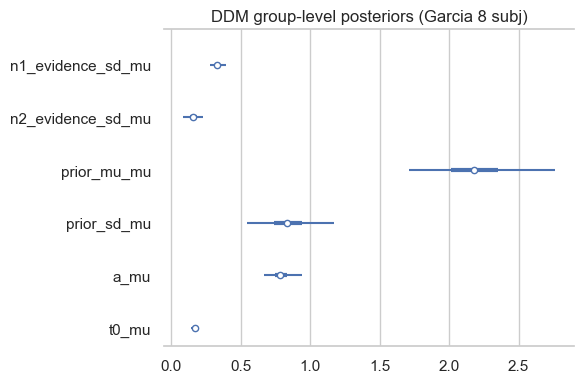

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
az.plot_forest(
    idata_ddm,
    var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu',
               'prior_mu_mu', 'prior_sd_mu', 'a_mu', 't0_mu'],
    combined=True, ax=ax,
)
ax.set_title('DDM group-level posteriors (Garcia 8 subj)')
plt.tight_layout()

### Posterior predictive: choice and the size effect

We draw 60 sets of subject-level parameters from the DDM posterior, simulate
(rt, choice) for the original paradigm with each, and compare to the data on
two functions:

- **Psychometric** — $P(\text{choose }2)$ vs $\log(n_2/n_1)$. The DDM has to
  match this, just like a static psychometric model.
- **Size-effect chronometric** — mean RT vs stake size, conditional on
  difficulty. This is the key RT signature a choice-only model cannot fit.

The PPC band is the 5–95% percentile interval over **per-bin posterior means**,
not over per-trial RT samples — so the band reflects parameter uncertainty,
not the (very large) within-trial diffusion noise.

In [ ]:
ppc_ddm = m_ddm.ppc(df, idata_ddm, n_posterior_samples=60, progressbar=False)
print(f"PPC shape: {ppc_ddm.shape}, columns: {list(ppc_ddm.columns)}")

PPC shape: (94080, 2), columns: ['simulated_rt', 'simulated_choice']


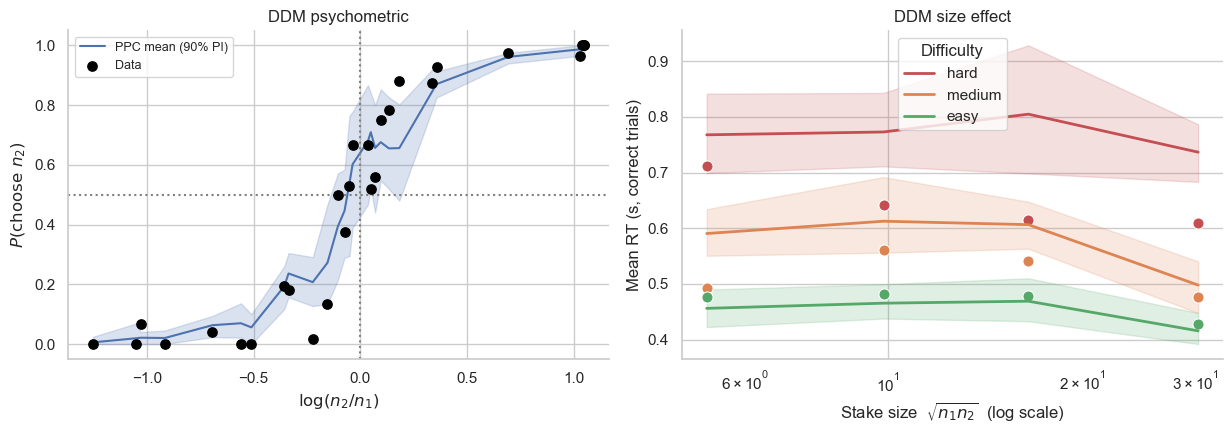

In [ ]:
def ppc_psychometric(df_data, ppc):
    """Long-format DataFrame: per (ppc_sample, log_ratio) the mean
    P(choose 2) across trials. Aggregated this way, the spread across
    ppc_samples *is* the posterior uncertainty in the psychometric."""
    d = df_data.copy()
    d['log_ratio'] = np.log(d['n2'] / d['n1'])
    p = ppc.join(d[['log_ratio']], how='left').reset_index()
    p['choice_int'] = p['simulated_choice'].astype(int)
    return (p.groupby(['ppc_sample', 'log_ratio'])
              ['choice_int'].mean().reset_index())


def ppc_size_effect(df_data, ppc, correct_only=True):
    """Long-format DataFrame: per (ppc_sample, stake_bin, diff_bin) the
    mean simulated_rt across trials. correct_only=True restricts to trials
    where the *simulated* choice agrees with n2 > n1."""
    d = add_bins(df_data)
    p = ppc.join(d[['stake_bin', 'stake_mid', 'diff_bin', 'n1', 'n2']],
                  how='left').reset_index()
    if correct_only:
        sim_correct = p['simulated_choice'].astype(bool) == (p['n2'] > p['n1'])
        p = p[sim_correct]
    return (p.groupby(['ppc_sample', 'stake_bin', 'stake_mid', 'diff_bin'],
                       observed=True)['simulated_rt'].mean().reset_index())


def plot_ppc_psychometric(df_data, ppc, ax=None, title=''):
    d = df_data.copy()
    d['log_ratio'] = np.log(d['n2'] / d['n1'])
    obs = (d.groupby('log_ratio')['choice']
             .apply(lambda x: x.astype(int).mean()).reset_index())
    pp = ppc_psychometric(df_data, ppc)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 4))
    sns.lineplot(data=pp, x='log_ratio', y='choice_int',
                 errorbar=('pi', 90), ax=ax, color='C0',
                 label='PPC mean (90% PI)')
    ax.scatter(obs['log_ratio'], obs['choice'], color='black', s=45,
               zorder=5, label='Data')
    ax.axhline(.5, c='gray', ls=':'); ax.axvline(0, c='gray', ls=':')
    ax.set_xlabel(r'$\log(n_2 / n_1)$')
    ax.set_ylabel(r'$P(\mathrm{choose}\ n_2)$')
    ax.set_title(title or 'Psychometric'); ax.legend(fontsize=9)
    sns.despine(ax=ax)
    return ax


def plot_ppc_size_effect(df_data, ppc, ax=None, title='', show_data=True):
    sub_obs = (add_bins(df_data).query('correct')
                .groupby(['subject', 'stake_bin', 'stake_mid', 'diff_bin'],
                          observed=True)['rt'].mean().reset_index())
    pp = ppc_size_effect(df_data, ppc)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    palette = {'hard': 'C3', 'medium': 'C1', 'easy': 'C2'}
    if show_data:
        sns.lineplot(data=sub_obs, x='stake_mid', y='rt', hue='diff_bin',
                     hue_order=['hard', 'medium', 'easy'], palette=palette,
                     errorbar=None, marker='o', ms=8, lw=0,
                     ax=ax, legend=False)
    sns.lineplot(data=pp, x='stake_mid', y='simulated_rt', hue='diff_bin',
                 hue_order=['hard', 'medium', 'easy'], palette=palette,
                 errorbar=('pi', 90), err_style='band',
                 err_kws={'alpha': 0.18}, lw=2, ax=ax)
    ax.set_xscale('log')
    ax.set_xlabel(r'Stake size  $\sqrt{n_1 n_2}$  (log scale)')
    ax.set_ylabel('Mean RT (s, correct trials)')
    ax.set_title(title or 'Size effect'); ax.legend(title='Difficulty')
    sns.despine(ax=ax)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
plot_ppc_psychometric(df, ppc_ddm, ax=axes[0], title='DDM psychometric')
plot_ppc_size_effect(df, ppc_ddm, ax=axes[1], title='DDM size effect')
plt.tight_layout()

The DDM psychometric tracks every data point cleanly — same as a static
psychometric model would. The right panel is the new test: filled markers are
the per-subject means in each (stake, difficulty) cell, lines+bands are the DDM
posterior predictive. The DDM **does** reproduce the size effect (RT decreases
with stake) and the difficulty ordering (hard slowest, easy fastest). The
mechanism is **prior shrinkage**: when both numbers are far from the inferred
prior mean, the Bayesian observer's posterior is pulled toward the prior
asymmetrically, leaving a residual drift that depends on stake.

## The Race-Diffusion Model

The RDM (Tillman, Van Zandt & Logan 2020; van Ravenzwaaij et al. 2020) takes a
different geometric view: instead of one accumulator integrating a signed
difference, **each option drives its own positive accumulator**, and the first
to hit the common boundary wins.

$$\mathrm{d}X_k(t) = v_k\, \mathrm{d}t + 1 \cdot \mathrm{d}W_k(t),
\qquad k \in \{1, 2\}$$

The first-passage time of accumulator $k$ to barrier $a$ is **inverse Gaussian**:

$$T_k \sim \mathrm{IG}\!\left(\mu_k = \frac{a}{v_k},\ \lambda_k = a^2\right)$$

(with diffusion noise fixed to $\sigma_k = 1$ — the standard convention; see
`notes/race_diffusion_math.md` for why this is the principled choice).

The race likelihood for "$k$ wins at time $t$" is the IG pdf of the winner
times the IG survival function of the loser:

$$\mathcal{L}(t, k) = f_{\mathrm{IG}}(t - t_0;\, \mu_k,\, a^2)
                      \cdot S_{\mathrm{IG}}(t - t_0;\, \mu_{\bar k},\, a^2)$$

bauer implements this in closed form (`logp_race_diffusion_2`) — no
likelihood-approximation networks (LANs) needed.

### Sequential evidence-stream interpretation

Conceptually, each accumulator's continuous Wiener noise $\sigma = 1$ *is* the
per-unit-time sensory noise. The accumulator's state at time $t$ is the agent's
running posterior estimate of $\log s_k$ given the evidence collected so far.
**Across-trial drift variability ($s_v$) is therefore not a separate parameter
— sensory uncertainty is fully expressed through the within-trial diffusion.**
Adding $s_v$ on top would double-count (Bogacz et al. 2006; Drugowitsch et al.
2012).

## The "advantage" decomposition (and why it matters)

A natural-looking choice for the per-accumulator drift is

$$v_k = w_0 + \tilde\mu_k, \qquad
\tilde\mu_k = \mu_{\text{post},k} - \mu_p \quad \text{(ablation)}$$

i.e. each accumulator's drift is the cognitive estimate of *its* option's
log-magnitude, plus a baseline urgency $w_0$. This is what we'll call
`advantage=False`. It seems sensible, but **it doesn't fit choice data
properly**.

The reason: under this parameterisation, drifts are nearly identical for the
two accumulators in any trial where both options are similarly above (or below)
the prior. The race's *relative* speed is driven only by tiny posterior
differences, while $w_0$ scales the *absolute* drift. With even modest noise,
the two accumulators race nearly neck-and-neck, and choice probabilities flatten
toward 0.5 regardless of $\log(n_2/n_1)$.

The fix (van Ravenzwaaij et al. 2020) is the **advantage decomposition**:

$$\boxed{\,v_i = w_0 + w_d \cdot (\tilde\mu_i - \tilde\mu_j) + w_s \cdot (\tilde\mu_i + \tilde\mu_j)\,}
\qquad i, j \in \{1, 2\},\ i \neq j$$

- **$w_0$** — baseline drift (urgency / non-evidence accumulation).
- **$w_d$** — *difference* sensitivity. Coefficient on the relative log-magnitude
  $\tilde\mu_i - \tilde\mu_j$, which has *opposite sign* for the two
  accumulators. This is the only term that creates discriminability.
- **$w_s$** — *summary* sensitivity. Coefficient on the (shared) total magnitude.
  Drives the size effect on RT (larger pairs $\Rightarrow$ both drifts scaled
  up $\Rightarrow$ faster races).

`advantage=True` is the bauer default. We'll fit both and let you see the
difference.

In [ ]:
# ── Fit the RDM (advantage=True, the default) ─────────────────────────────
# RDM with fit_prior=True needs more warmup than the DDM — see
# notes/race_diffusion_math.md §5 for the identifiability geometry.
m_rdm = RaceDiffusionMagnitudeComparisonModel(
    paradigm=df,
    fit_separate_evidence_sd=True,
    fit_prior=True,
    advantage=True,
)
idata_rdm = fit_or_load(m_rdm, 'rdm', tune=1500, target_accept=0.98)

Loading cached rdm fit from /Users/gdehol/.bauer_tutorial_cache/garcia_n8_rtmin200_rdm.nc


In [ ]:
diag = az.summary(
    idata_rdm,
    var_names=['a_mu', 't0_mu', 'w_0_mu', 'w_d_mu', 'w_s_mu',
               'n1_evidence_sd_mu', 'n2_evidence_sd_mu',
               'prior_mu_mu', 'prior_sd_mu'],
    kind='diagnostics',
)
print(diag)
print(f"\nDivergences: {int(idata_rdm.sample_stats['diverging'].sum())}")
print(f"Max r̂:       {float(diag['r_hat'].max()):.3f}")

                   mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
a_mu                   0.004    0.003    1000.0    1700.0   1.00
t0_mu                  0.000    0.001    1696.0    1216.0   1.00
w_0_mu                 0.022    0.027     294.0     403.0   1.01
w_d_mu                 0.005    0.004    2021.0    1628.0   1.00
w_s_mu                 0.001    0.001    1789.0    1594.0   1.00
n1_evidence_sd_mu      0.002    0.002    1816.0    1817.0   1.00
n2_evidence_sd_mu      0.002    0.002    2033.0    2102.0   1.00
prior_mu_mu            0.007    0.006    1680.0    1566.0   1.00
prior_sd_mu            0.004    0.004    1625.0    1824.0   1.00

Divergences: 1
Max r̂:       1.010


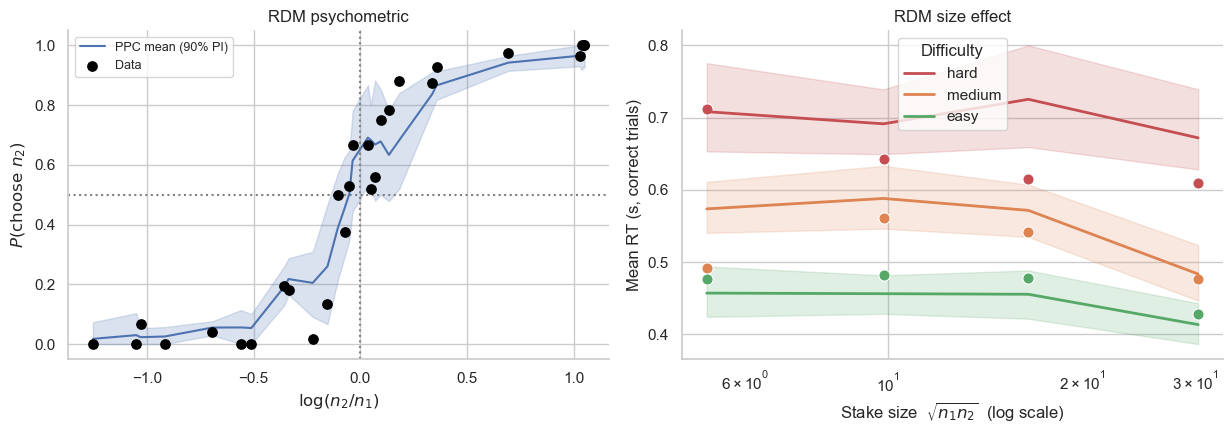

In [ ]:
ppc_rdm = m_rdm.ppc(df, idata_rdm, n_posterior_samples=60, progressbar=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
plot_ppc_psychometric(df, ppc_rdm, ax=axes[0], title='RDM psychometric')
plot_ppc_size_effect(df, ppc_rdm, ax=axes[1], title='RDM size effect')
plt.tight_layout()

The RDM also fits the psychometric and reproduces the size effect, but
through a *different* mechanism: the **summary** drift coefficient $w_s$
multiplies $(\tilde\mu_1 + \tilde\mu_2)$, so increasing the total magnitude
literally raises the drift on **both** accumulators in tandem. That makes the
race finish faster regardless of which side wins.

## How DDM and RDM look *different*

Both models fit the choice and the size effect well, so on these summaries
they're nearly indistinguishable. Where do they actually diverge?

### 1. The size effect, side by side

Plotting both PPC bands on the same axes makes the small-but-systematic
differences visible — the RDM's size effect is typically a hair *steeper*
than the DDM's, because $w_s$ amplifies the magnitude effect directly while
the DDM only gets it through the cognitive front-end.

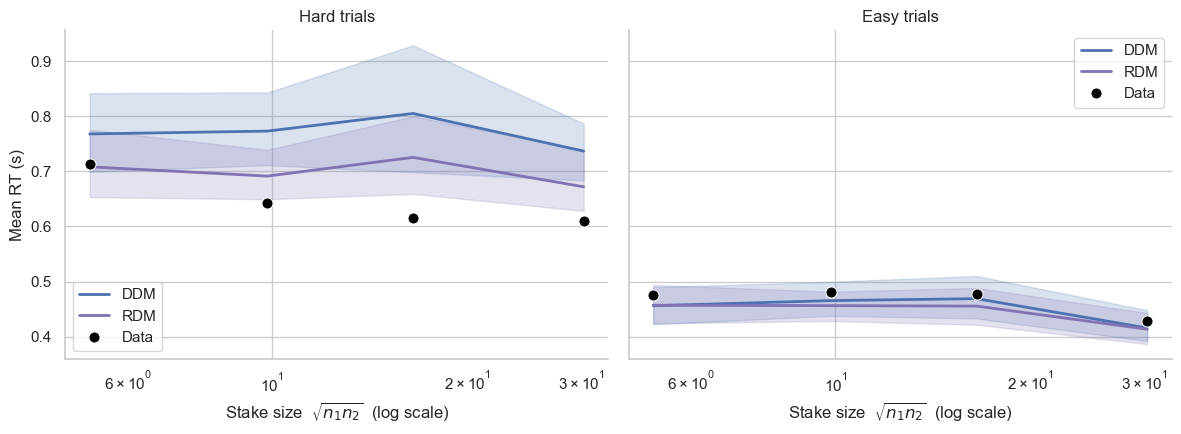

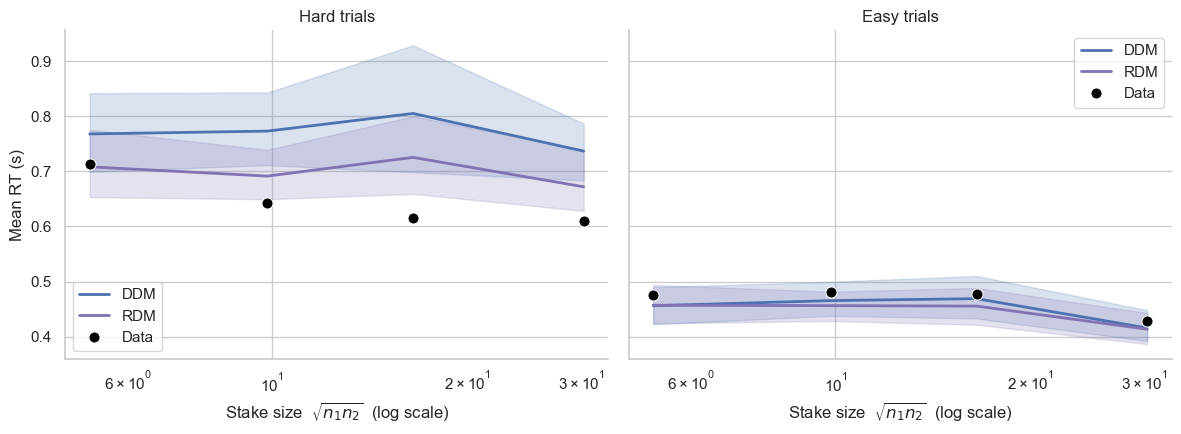

In [ ]:
def plot_size_effect_comparison(df_data, ppcs, palette=None):
    """Overlay multiple models' size-effect PPCs in two panels — one panel
    per difficulty bin extreme (hard vs easy) so the curve shapes are
    legible."""
    sub_obs = (add_bins(df_data).query('correct')
                .groupby(['subject', 'stake_bin', 'stake_mid', 'diff_bin'],
                          observed=True)['rt'].mean().reset_index())
    pp_models = []
    for name, ppc in ppcs.items():
        pp = ppc_size_effect(df_data, ppc)
        pp['model'] = name
        pp_models.append(pp)
    pp_long = pd.concat(pp_models, ignore_index=True)
    if palette is None:
        palette = {'DDM': 'C0', 'RDM': 'C4'}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, diff in zip(axes, ['hard', 'easy']):
        d_obs = sub_obs[sub_obs['diff_bin'] == diff]
        d_pp = pp_long[pp_long['diff_bin'] == diff]
        sns.lineplot(data=d_pp, x='stake_mid', y='simulated_rt', hue='model',
                      palette=palette, errorbar=('pi', 90),
                      err_style='band', err_kws={'alpha': 0.2}, lw=2, ax=ax)
        sns.lineplot(data=d_obs, x='stake_mid', y='rt', errorbar=None,
                      marker='o', ms=8, lw=0, color='black', ax=ax,
                      label='Data', legend=True)
        ax.set_xscale('log')
        ax.set_xlabel(r'Stake size  $\sqrt{n_1 n_2}$  (log scale)')
        ax.set_ylabel('Mean RT (s)')
        ax.set_title(f'{diff.capitalize()} trials')
        sns.despine(ax=ax)
    plt.tight_layout()
    return fig


plot_size_effect_comparison(df, {'DDM': ppc_ddm, 'RDM': ppc_rdm})

### 2. Choice-conditional RT: correct vs error

The classic textbook discriminator. Under bauer's basic DDM (unbiased start
$z=0.5$, no across-trial drift variability $s_v$), the Wiener first-passage
density is symmetric in the sign of drift — so **mean RT for correct
responses equals mean RT for errors**. With variability (e.g. $s_v$), the
DDM produces *fast errors* (drift draws below threshold lead to faster
mistakes); without variability, mean(RT|error) = mean(RT|correct).

The race-diffusion model does **not** share that symmetry. Each accumulator
has its own inverse-Gaussian first-passage time. When the "wrong" accumulator
wins despite a smaller drift, it must do so via a left-tail draw — but the
winning IG distribution conditioned on winning has a longer mean than
the losing one's mean. Result: **mean(RT|error) > mean(RT|correct)** in
the RDM, more so on easier trials where drift differences are largest.

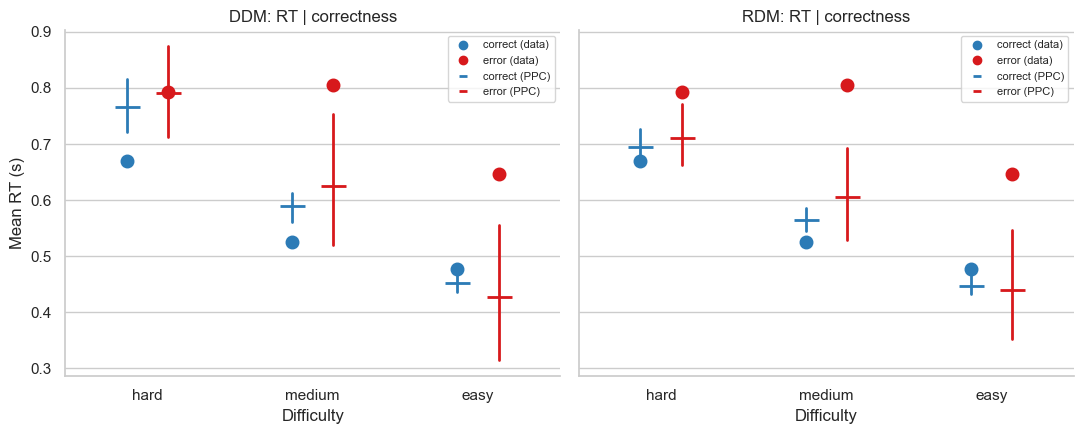

In [ ]:
def conditional_rt(df_data, ppc, kind):
    """kind='data' uses df_data['rt']; kind='ppc' uses ppc."""
    d = add_bins(df_data)
    if kind == 'data':
        out = (d.groupby(['diff_bin', 'correct'], observed=True)['rt']
                 .mean().reset_index().rename(columns={'rt': 'mean_rt'}))
        out['source'] = 'Data'
        return out
    p = ppc.join(d[['diff_bin', 'n1', 'n2']], how='left').reset_index()
    p['sim_correct'] = p['simulated_choice'].astype(bool) == (p['n2'] > p['n1'])
    return (p.groupby(['ppc_sample', 'diff_bin', 'sim_correct'],
                       observed=True)['simulated_rt'].mean()
              .reset_index().rename(columns={'simulated_rt': 'mean_rt',
                                              'sim_correct': 'correct'}))


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
hue_order = [True, False]
hue_labels = {True: 'correct', False: 'error'}
palette = {True: '#2c7bb6', False: '#d7191c'}

for ax, name, ppc in [(axes[0], 'DDM', ppc_ddm), (axes[1], 'RDM', ppc_rdm)]:
    d_obs = conditional_rt(df, None, 'data')
    d_pp = conditional_rt(df, ppc, 'ppc')

    sns.pointplot(data=d_pp, x='diff_bin', y='mean_rt', hue='correct',
                  hue_order=hue_order, palette=palette,
                  order=['hard', 'medium', 'easy'],
                  errorbar=('pi', 90), dodge=0.25, ax=ax,
                  marker='_', linestyles='none', markersize=18,
                  err_kws={'linewidth': 2}, legend=False)
    sns.pointplot(data=d_obs, x='diff_bin', y='mean_rt', hue='correct',
                  hue_order=hue_order, palette=palette,
                  order=['hard', 'medium', 'easy'],
                  errorbar=None, dodge=0.25, ax=ax,
                  markers='o', markersize=8, linestyles='none', legend=False)
    # Manual legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], marker='o', ls='', color=palette[True],  label='correct (data)'),
        Line2D([0], [0], marker='o', ls='', color=palette[False], label='error (data)'),
        Line2D([0], [0], marker='_', ls='', color=palette[True],  label='correct (PPC)', mew=2),
        Line2D([0], [0], marker='_', ls='', color=palette[False], label='error (PPC)',   mew=2),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper right')
    ax.set_title(f'{name}: RT | correctness')
    ax.set_xlabel('Difficulty')
    ax.set_ylabel('Mean RT (s)')
    sns.despine(ax=ax)

plt.tight_layout()

Look at the easier difficulty levels: in the data, errors tend to be slightly
slower than corrects (a small but classic finding). The DDM PPC has the
correct/error markers nearly stacked — its predicted means are essentially
equal because there's no across-trial drift variability. The RDM PPC has them
visibly separated, with errors above corrects, especially on easy trials.

If your data show **fast errors** (errors *faster* than corrects), neither of
these models will fit it cleanly — you'd need a DDM with $s_v$ added, or a
race model with starting-point variability.

## The ablation: `advantage=False` produces a flat psychometric

We now fit the same race model with the simpler decomposition $v_k = w_0 + \tilde\mu_k$
and plot its psychometric. This run is shorter (smaller draws, fewer chains)
because the goal is just to demonstrate the failure mode, not to draw
conclusions from the posterior.

In [ ]:
m_rdm_noadv = RaceDiffusionMagnitudeComparisonModel(
    paradigm=df,
    fit_separate_evidence_sd=True,
    fit_prior=True,
    advantage=False,   # the ablation
)
idata_rdm_noadv = fit_or_load(m_rdm_noadv, 'rdm_noadv',
                                draws=400, tune=400, chains=2)

Initializing NUTS using adapt_full...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, prior_mu_mu, prior_mu_sd, prior_mu_offset, prior_sd_mu_untransformed, prior_sd_sd, prior_sd_offset, w_0_mu_untransformed, w_0_sd, w_0_offset, a_mu_untransformed, a_sd, a_offset, t0_mu_untransformed, t0_sd, t0_offset]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 123 seconds.


There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved rdm_noadv fit to /Users/gdehol/.bauer_tutorial_cache/garcia_n8_rtmin200_rdm_noadv.nc


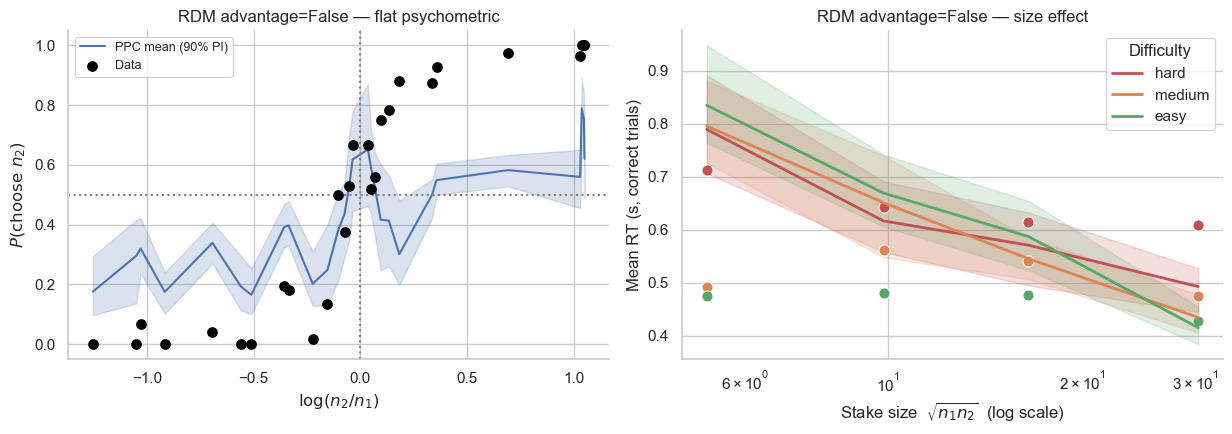

In [ ]:
ppc_noadv = m_rdm_noadv.ppc(df, idata_rdm_noadv, n_posterior_samples=40,
                              progressbar=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
plot_ppc_psychometric(df, ppc_noadv, ax=axes[0],
                       title='RDM advantage=False — flat psychometric')
plot_ppc_size_effect(df, ppc_noadv, ax=axes[1],
                      title='RDM advantage=False — size effect')
plt.tight_layout()

You should see the psychometric in the right-hand model has lost most of its
slope: the PPC mean is nearly flat, hovering near 0.5 across the entire range
of $\log(n_2/n_1)$. The data points are way above and below the model.

**Why this happens, mechanically.** With both accumulators starting from zero
and drifting at $w_0 + \tilde\mu_k$ where $w_0$ dominates, the two races are
driven by *almost the same* drift rate. The Wiener noise then dominates the
relative timing, so choice is near-random. The model can still fit RT
*magnitudes* (because $w_0$ controls overall race speed), but it cannot select
between the options based on log-magnitude.

The advantage form solves this by giving the two accumulators **opposite-signed**
drift contributions from the difference term, $\pm w_d (\tilde\mu_1 - \tilde\mu_2)$,
so even small log-ratios produce systematic drift asymmetries.

This is why bauer's race models default to `advantage=True`. The bauer source
explicitly warns against the ablation in `bauer/models/race.py` and the
project-level CLAUDE.md.

## Choosing between the DDM and the RDM

Both models use the same Bayesian-observer front-end and produce highly similar
fits to choice + RT data. Practical considerations:

| | DDM | RDM (advantage) |
|---|---|---|
| **Likelihood** | Wiener WFPT (HSSM) — analytic, fast | Inverse-Gaussian race — analytic, slightly faster |
| **Free params (beyond cognitive)** | $a, t_0$ (and optional $z, v_{\text{scale}}$) | $a, t_0, w_0, w_d, w_s$ |
| **Geometric story** | Single signed evidence stream | Two parallel evidence streams |
| **Multi-alternative extension** | Hard (no clean signed-evidence in $K$ alternatives) | Trivial: add one accumulator per option |
| **Starting-point bias $z$** | Yes (response bias before evidence) | No (each accumulator starts at 0) |
| **Size effect on RT** | Indirect via prior shrinkage | Direct via $w_s$ |
| **Identifiability** | Clean — drift uses SNR, $\sigma_p$ enters drift mean only | Clean once $\sigma=1$ is fixed (see notes/race_diffusion_math.md §6) |

In bauer, all four classes (`DDM*ComparisonModel`, `DDM*RiskModel`,
`RaceDiffusion*ComparisonModel`, `RaceDiffusion*RiskModel`) are drop-in
replacements for the static-choice base classes, so you can swap freely once
your data has an `rt` column (in seconds, $> 0$).

For risky-choice tasks, both DDM and RDM variants exist (`DDMRiskModel`,
`RaceDiffusionRiskModel`) and use the same `_drift_from_snr` /
`_drifts_from_post_and_prior` machinery — probabilities enter as a deterministic
shift $\log(p_2/p_1)$ on the perceived log-magnitude difference (see
`bauer/models/ddm.py` and `bauer/models/race.py`).

## Take-aways

- **RT carries information that choice-only models discard.** The size effect
  is the cleanest demo: faster RTs at larger stakes at fixed difficulty.
  A static psychometric model cannot predict it at all.
- **The DDM and RDM share the same Bayesian-observer cognitive front-end.**
  They differ only in the decision rule: a single signed accumulator vs two
  racing accumulators.
- **Both reproduce the size effect, by different mechanisms.** The DDM gets
  it through prior shrinkage on the perceived log-magnitude difference. The
  RDM gets it explicitly via $w_s$, the summary-of-magnitudes drift
  coefficient.
- **The textbook DDM/RDM dissociator is choice-conditional RT.** Bauer's DDM
  (no $s_v$) predicts mean(RT|correct) = mean(RT|error). The RDM predicts
  mean(RT|error) > mean(RT|correct), more so on easier trials. If your data
  show the *opposite* — fast errors — neither basic model will fit, and you
  need to add across-trial variability ($s_v$).
- **Aggregate before computing the PPC band.** Per-(ppc_sample, bin) means
  give a band that reflects parameter uncertainty; raw per-trial values give
  a band dominated by within-trial Wiener noise (visually huge, not what you
  want).
- **Use `advantage=True` for race models.** The simpler $v_k = w_0 + \tilde\mu_k$
  decomposition is theoretically appealing but produces a flat psychometric
  in practice — the difference term $w_d (\tilde\mu_i - \tilde\mu_j)$ is
  what gives the race its discriminability.
- **Diagnostics first.** $\hat r \le 1.01$, ESS bulk $\ge 100$/chain, and few
  divergences before interpreting any posterior. RDM with `fit_prior=True`
  often needs `tune=1500` and `target_accept=0.98` (we used those above).

Next steps in the bauer ecosystem:

- **Flexible noise** — `DDMFlexibleNoise*Model` / `RaceDiffusionFlexibleNoise*Model`
  swap scalar $\nu_k$ for a B-spline $\sigma_k(n)$, just like in lesson 4.
- **Regression on accumulator parameters** —
  `DDMFlexibleNoiseRiskRegressionModel` and the race equivalent let you put a
  patsy formula on $a$, $t_0$, $w_0$, etc. (e.g. `regressors={'a':
  'stimulation_condition'}` for TMS designs).
- **JAX backends** — set `backend='numpyro'` in `m.sample()` for ~3–10× speed-up
  on CPU and 5–30× on GPU (see CLAUDE.md). The pymc backend used here works
  out-of-the-box but is slower for these models.